In [1]:
# import statsmodels.api as sm

import os
import pickle
import sys
# Prefer adding the project root so packages like baseVR import correctly
sys.path.insert(0, "/home/amitsant2000/ethz/VirtualReality")
# Keep analysisVR for legacy absolute imports like `analytics_processing.*`
sys.path.append("/home/amitsant2000/ethz/VirtualReality/analysisVR")
sys.path.append("/home/amitsant2000/ethz/VirtualReality/ephysVR")


In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# %matplotlib qt
%matplotlib widget

from analytics_processing import analytics
import analytics_processing.analytics_constants as C
from CustomLogger import CustomLogger as Logger

from dashsrc.plot_components.plot_wrappers.data_selection import group_filter_data

from analytics_processing.modality_loading import session_modality_from_nas
from analytics_processing.sessions_from_nas_parsing import sessionlist_fullfnames_from_args
from analytics_processing.sessions_from_nas_parsing import fullfnames2snames


In [ ]:
output_dir = "./outputs/experimental/"
data = {}
nas_dir = "/mnt/z/BMI/VirtualReality/SpatialSequenceLearning/" #C.device_paths()[0]
Logger().init_logger(None, None, logging_level="DEBUG")



In [4]:
# ephys
paradigm_ids = [1100]
animal_ids = [6]
session_ids = None
# animal_ids = [10]
# session_ids = [10]
# width = 1400
# height = 1400
# group_by = None

session_modality_from_nas

<function analytics_processing.modality_loading.session_modality_from_nas(session_fullfname, key, where=None, start=None, stop=None, columns=None)>

In [5]:
session_dirs = sessionlist_fullfnames_from_args(paradigm_ids, animal_ids, session_ids)[0]


2025-11-29 00:44:13,686|DEBUG|3602|sessions_from_nas_parsing|get_sessionlist_fullfnames
	Searching NAS for applicable sessions...


NAS directory not found: /mnt/nas/BMI/VirtualReality/SpatialSequenceLearning/ - VPN connected?


FileNotFoundError: NAS directory not found: /mnt/nas/BMI/VirtualReality/SpatialSequenceLearning/ - VPN connected?

In [7]:
session_dirs

NameError: name 'session_dirs' is not defined

In [8]:
session_names = fullfnames2snames(session_dirs)
# df = analytics.get_analytics('TrackKinematics', session_names=session_names)

NameError: name 'session_dirs' is not defined

In [9]:
session_names = fullfnames2snames(session_dirs)
kinematics = analytics.get_analytics('TrackKinematics', session_names=session_names)
d = (kinematics.groupby(level='session_id').apply(lambda x: x.iloc[0].loc['frame_ephys_timestamp'] if not x.empty else None))
d = d.dropna()

plt.hist(d,)
plt.show()

NameError: name 'session_dirs' is not defined

In [9]:
kinematics.head()

frame_id  frame_pc_timestamp  \
paradigm_id animal_id session_id entry_id                                 
6           1100      0          0            14109    1731592882746345   
                                 1            14110    1731592882763007   
                                 2            14111    1731592882779674   
                                 3            14112    1731592882797859   
                                 4            14113    1731592882814538   

                                           frame_position  frame_state  \
paradigm_id animal_id session_id entry_id                                
6           1100      0          0                    0.0         1119   
                                 1                    0.0         1119   
                                 2                    0.0         1119   
                                 3                    0.0         1119   
                                 4                    0.0         1119   

                                           ballvelocity_first_package  \
paradigm_id animal_id session_id entry_id                               
6           1100      0          0                          902934952   
                                 1                          902934976   
                                 2                          902935039   
                                 3                          902935086   
                                 4                          902935127   

                                           ballvelocity_last_package  \
paradigm_id animal_id session_id entry_id                              
6           1100      0          0                         902934975   
                                 1                         902935038   
                                 2                         902935085   
                                 3                         902935126   
                                 4                         902935165   

                                           frame_ephys_timestamp  trial_id  \
paradigm_id animal_id session_id entry_id                                    
6           1100      0          0                          <NA>        -1   
                                 1                          <NA>        -1   
                                 2                          <NA>        -1   
                                 3                          <NA>        -1   
                                 4                          <NA>        -1   

                                           frame_ephys_patched  \
paradigm_id animal_id session_id entry_id                        
6           1100      0          0                        <NA>   
                                 1                        <NA>   
                                 2                        <NA>   
                                 3                        <NA>   
                                 4                        <NA>   

                                           from_cm_position_bin  \
paradigm_id animal_id session_id entry_id                         
6           1100      0          0                            0   
                                 1                            0   
                                 2                            0   
                                 3                            0   
                                 4                            0   

                                           to_cm_position_bin track_zone  \
paradigm_id animal_id session_id entry_id                                  
6           1100      0          0                          1       cue2   
                                 1                          1       cue2   
                                 2                          1       cue2   
                                 3                          1       cue2   
                                 4           

In [10]:
columns = ['frame_pc_timestamp', 'frame_raw', 'frame_yaw', 
          'frame_pitch', 'frame_acceleration', 'frame_velocity']
kinematics_filtered = kinematics[columns]

In [11]:
kinematics_filtered.head()

frame_pc_timestamp  frame_raw  \
paradigm_id animal_id session_id entry_id                                  
6           1100      0          0           1731592882746345       <NA>   
                                 1           1731592882763007          3   
                                 2           1731592882779674          0   
                                 3           1731592882797859         -1   
                                 4           1731592882814538          0   

                                           frame_yaw  frame_pitch  \
paradigm_id animal_id session_id entry_id                           
6           1100      0          0              <NA>         <NA>   
                                 1                 0           -1   
                                 2                 0           -2   
                                 3                 1           -2   
                                 4                -1           -4   

                                           frame_acceleration  frame_velocity  
paradigm_id animal_id session_id entry_id                                      
6           1100      0          0                        0.0             0.0  
                                 1                        0.0             0.0  
                                 2                        0.0             0.0  
                                 3                        0.0             0.0  
                                 4                        0.0             0.0

In [12]:
# Interpolate <NA> values in frame_raw, frame_yaw, frame_pitch, frame_acceleration, and frame_velocity columns
to_interpolate = ['frame_raw', 'frame_yaw', 'frame_pitch', 'frame_acceleration', 'frame_velocity']

# Interpolate by group (over columns, using the frame_pc_timestamp as the interpolation axis)
# The index is multi-level: paradigm_id, animal_id, session_id, entry_id
# We'll interpolate within each session_id.

# First, reset index to get columns we can group by
kinematics_filtered_reset = kinematics_filtered.reset_index()

# Only interpolate over numeric columns, so ensure type conversion
for col in to_interpolate + ['frame_pc_timestamp']:
    # For safety, convert to float (if <NA> or mixed types)
    kinematics_filtered_reset[col] = pd.to_numeric(kinematics_filtered_reset[col], errors='coerce')

def interp_group(df):
    # set index as frame_pc_timestamp and interpolate on that axis
    df_sorted = df.sort_values('frame_pc_timestamp')
    df_interp = df_sorted.copy()
    df_interp[to_interpolate] = df_sorted[to_interpolate].interpolate(
        method='linear',
        limit_direction='both',
        axis=0
    )
    return df_interp

# Group by paradigm_id, animal_id, session_id, and interpolate within each group
kinematics_filtered_interp = kinematics_filtered_reset.groupby(
    ['paradigm_id', 'animal_id', 'session_id'],
    group_keys=False
).apply(interp_group)

# Set back the previous index order
kinematics_filtered_interp.set_index(['paradigm_id', 'animal_id', 'session_id', 'entry_id'], inplace=True)
# Ensure the columns are in the same order as before
kinematics_filtered_interp = kinematics_filtered_interp[kinematics_filtered.columns]

# Now kinematics_filtered_interp contains interpolated values in place of <NA>


/tmp/ipykernel_16353/575440935.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(interp_group)


In [13]:
kinematics_filtered_interp.head()

frame_pc_timestamp  frame_raw  \
paradigm_id animal_id session_id entry_id                                  
6           1100      0          0           1731592882746345        3.0   
                                 1           1731592882763007        3.0   
                                 2           1731592882779674        0.0   
                                 3           1731592882797859       -1.0   
                                 4           1731592882814538        0.0   

                                           frame_yaw  frame_pitch  \
paradigm_id animal_id session_id entry_id                           
6           1100      0          0               0.0         -1.0   
                                 1               0.0         -1.0   
                                 2               0.0         -2.0   
                                 3               1.0         -2.0   
                                 4              -1.0         -4.0   

                                           frame_acceleration  frame_velocity  
paradigm_id animal_id session_id entry_id                                      
6           1100      0          0                        0.0             0.0  
                                 1                        0.0             0.0  
                                 2                        0.0             0.0  
                                 3                        0.0             0.0  
                                 4                        0.0             0.0

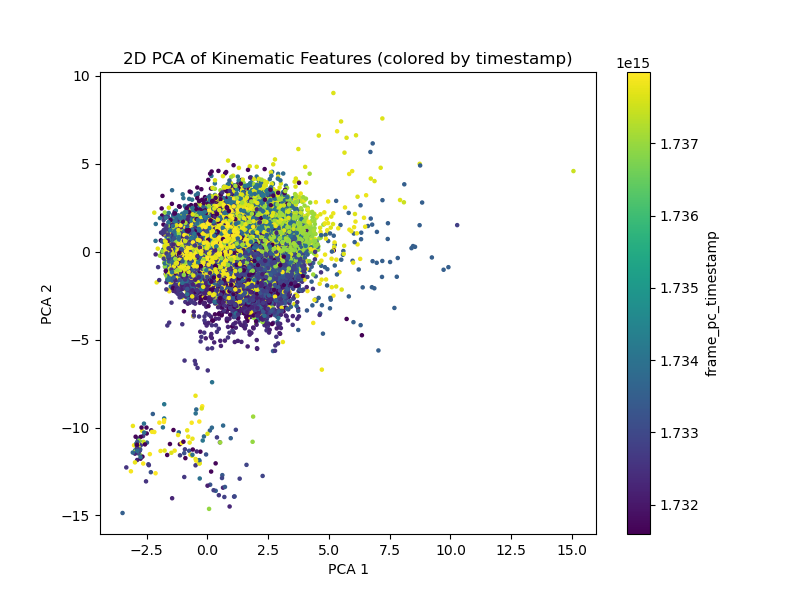

In [14]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Get the numeric columns to use for PCA (exclude the timestamp column)
features = [col for col in kinematics_filtered_interp.columns if col not in ['frame_pc_timestamp']]
data_for_pca = kinematics_filtered_interp[features]

# Drop rows with any remaining NaN (should be none after interpolation, but for safety)
data_for_pca = data_for_pca.dropna()

timestamps = kinematics_filtered_interp.loc[data_for_pca.index, 'frame_pc_timestamp']

# Standardize (PCA works best on standardized data)
from sklearn.preprocessing import StandardScaler
data_std = StandardScaler().fit_transform(data_for_pca)

# Perform PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(data_std)

# If the data is large, sample 5000 points for plotting/analysis (or less if less rows)
max_samples = 100000
if len(pca_result) > max_samples:
    sampled_indices = np.random.choice(len(pca_result), max_samples, replace=False) 
    pca_result = pca_result[sampled_indices]
    timestamps = timestamps.iloc[sampled_indices]

# Plot
plt.figure(figsize=(8, 6))
sc = plt.scatter(pca_result[:,0], pca_result[:,1], c=timestamps, cmap='viridis', s=5)
plt.colorbar(sc, label='frame_pc_timestamp')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('2D PCA of Kinematic Features (colored by timestamp)')
plt.show()


In [15]:
len(kinematics_filtered_interp)

4094208

In [16]:
# PCA plot colored by 'track_zone' instead of timestamp

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
import numpy as np

# Get the numeric columns to use for PCA (exclude timestamp and non-numeric columns)
features = [col for col in kinematics_filtered_interp.columns if col not in ['frame_pc_timestamp', 'track_zone']]
data_for_pca = kinematics_filtered_interp[features]

# Drop rows with any remaining NaN (should be none after interpolation, but for safety)
data_for_pca = data_for_pca.dropna()

kinematics_filtered_interp.index = kinematics_filtered_interp['frame_pc_timestamp']
kinematics.index = kinematics['frame_pc_timestamp']

kinematics_filtered_interp = kinematics_filtered_interp.join(kinematics)

# Get corresponding track_zone values
track_zones = kinematics_filtered_interp.loc[data_for_pca.index, 'track_zone']

# Standardize features
data_std = StandardScaler().fit_transform(data_for_pca)

# Perform PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(data_std)

# If data is large, sample points for plotting
max_samples = 100000
if len(pca_result) > max_samples:
    sampled_indices = np.random.choice(len(pca_result), max_samples, replace=False)
    pca_result = pca_result[sampled_indices]
    track_zones = track_zones.iloc[sampled_indices]

# Encode categorical track_zone for coloring
le = LabelEncoder()
track_zone_encoded = le.fit_transform(track_zones)

plt.figure(figsize=(8, 6))
# Make a scatterplot with one color per track_zone category
scatter = plt.scatter(
    pca_result[:, 0],
    pca_result[:, 1],
    c=track_zone_encoded,
    cmap='tab10',  # Can choose e.g. 'tab20' or 'Set1' if more than 10 categories
    s=5
)

# Produce a legend matching color to track_zone label
handles, _ = scatter.legend_elements(num=len(le.classes_))
plt.legend(handles, le.classes_, title="track_zone", loc="best", bbox_to_anchor=(1.01, 1.0))
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('2D PCA of Kinematic Features (colored by track_zone)')
plt.tight_layout()
plt.show()

ValueError: columns overlap but no suffix specified: Index(['frame_pc_timestamp', 'frame_raw', 'frame_yaw', 'frame_pitch',
       'frame_acceleration', 'frame_velocity'],
      dtype='object')

In [22]:
spikes_df = analytics.get_analytics('ConcatenatedEnsambleProj40ms', session_names=session_names, animal_ids=animal_ids, paradigm_ids=paradigm_ids)
spikes_df.head()


2025-10-29 01:41:55,734|DEBUG|16353|sessions_from_nas_parsing|sessionnames2fullfnames
	Inferring NAS paths for list of session names...
2025-10-29 01:41:57,117|DEBUG|16353|sessions_from_nas_parsing|sessionlist_fullfnames_from_args
	Paradigm_ids: [1100], animal_ids: [6], session_ids: None, from_date: None, to_date: None
	Merging 34 sessions

2025-10-29 01:41:57,118|DEBUG|16353|analytics|get_analytics
	Processing ConcatenatedEnsambleProj40ms, for n=34 sessions


/mnt/nas/BMI/VirtualReality/SpatialSequenceLearning/RUN_rYL006/rYL006_P1100/2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min/../../animal_analytics/ConcatenatedEnsambleProj40ms.parquet


,session_id,from_ephys_timestamp,to_ephys_timestamp,Assembly001,Assembly002,Assembly003,Assembly004,Assembly005,Assembly006,Assembly007,...,Assembly014,Assembly015,Assembly016,Assembly017,Assembly018,Assembly019,Assembly020,Assembly021,Assembly022,Assembly023
0,1,0,40000,0.026852,-0.085575,-0.020219,-0.102360,0.040032,0.407487,0.083296,...,-0.042139,0.408235,1.328211,0.077043,0.068470,-0.133849,0.476907,-0.128346,-0.103792,0.306191
1,1,40000,80000,-0.024060,0.029410,-0.051341,0.000979,0.032214,0.323515,0.199857,...,-0.026088,0.054523,0.967675,0.145873,0.350299,-0.108111,0.961131,-0.180058,-0.019387,-0.073137
2,1,80000,120000,0.083996,-0.141831,0.010751,-0.136072,0.049860,0.508357,0.024676,...,-0.091429,0.735748,1.469023,0.051062,-0.150470,-0.145186,0.130214,-0.008392,-0.191949,0.505517
3,1,120000,160000,0.186976,-0.063750,0.031752,-0.103275,0.169140,0.188209,0.104219,...,-0.064751,0.232497,1.659276,-0.134382,-0.000748,-0.097976,-0.125448,-0.228286,0.039825,-0.526319
4,1,160000,200000,-0.010344,0.323889,-0.073934,0.309452,0.173009,0.042274,0.241668,...,0.198879,0.064732,0.316930,0.033783,0.090853,-0.014680,0.033293,-0.210339,0.087722,-0.207375


In [19]:
ensemble_df = analytics.get_analytics('Ensemble40msProjEventAligned', session_names=session_names, animal_ids=animal_ids, paradigm_ids=paradigm_ids)

2025-10-29 01:39:52,766|DEBUG|16353|sessions_from_nas_parsing|sessionnames2fullfnames
	Inferring NAS paths for list of session names...
2025-10-29 01:39:54,183|DEBUG|16353|sessions_from_nas_parsing|sessionlist_fullfnames_from_args
	Paradigm_ids: [1100], animal_ids: [6], session_ids: None, from_date: None, to_date: None
	Merging 34 sessions

2025-10-29 01:39:54,185|DEBUG|16353|analytics|get_analytics
	Processing Ensemble40msProjEventAligned, for n=34 sessions


/mnt/nas/BMI/VirtualReality/SpatialSequenceLearning/RUN_rYL006/rYL006_P1100/2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min/../../animal_analytics/Ensemble40msProjEventAligned.parquet


In [20]:
ensemble_df.head()

,interval_t,trial_id,cue,trial_outcome,choice_R1,choice_R2,t0_event_name,t0,t_interval,interval_batch_id,...,Assembly015,Assembly016,Assembly017,Assembly018,Assembly019,Assembly020,Assembly021,Assembly022,Assembly023,session_id
0,0,1,1.0,0.0,0.0,0.0,enter_cueZone,5420000,"(4420000, 6420000]",0,...,-0.217237,2.742173,-0.226708,-0.094440,-0.234512,-0.400145,-0.700575,-0.121225,-1.949975,1
1,1,1,1.0,0.0,0.0,0.0,enter_cueZone,5420000,"(4420000, 6420000]",0,...,-0.365734,3.855618,-2.762292,-3.112726,-0.565940,1.512761,6.063891,3.810302,-0.481167,1
2,2,1,1.0,0.0,0.0,0.0,enter_cueZone,5420000,"(4420000, 6420000]",0,...,-0.444365,0.833919,-0.217744,-0.028983,1.824705,-0.487887,-0.355964,1.078372,-0.153196,1
3,3,1,1.0,0.0,0.0,0.0,enter_cueZone,5420000,"(4420000, 6420000]",0,...,1.053253,2.595468,-0.372019,-0.346092,-0.175874,-0.552639,-0.150977,-0.211083,-0.774682,1
4,4,1,1.0,0.0,0.0,0.0,enter_cueZone,5420000,"(4420000, 6420000]",0,...,0.884796,2.314073,-1.155362,-0.479509,0.070917,-0.063552,-0.828901,1.398429,1.333650,1


In [21]:
ensemble_df.columns

Index(['interval_t', 'trial_id', 'cue', 'trial_outcome', 'choice_R1',
       'choice_R2', 't0_event_name', 't0', 't_interval', 'interval_batch_id',
       'ephys_bin_t', 'Assembly001', 'Assembly002', 'Assembly003',
       'Assembly004', 'Assembly005', 'Assembly006', 'Assembly007',
       'Assembly008', 'Assembly009', 'Assembly010', 'Assembly011',
       'Assembly012', 'Assembly013', 'Assembly014', 'Assembly015',
       'Assembly016', 'Assembly017', 'Assembly018', 'Assembly019',
       'Assembly020', 'Assembly021', 'Assembly022', 'Assembly023',
       'session_id'],
      dtype='object')

In [22]:
behavior_df = analytics.get_analytics('BehaviorFramewise', session_names=session_names, animal_ids=animal_ids, paradigm_ids=paradigm_ids)
# behavior_df[behavior_df["frame_ephys_timestamp"].isnotna()].head()

2025-10-29 11:08:16,661|DEBUG|3385|sessions_from_nas_parsing|sessionnames2fullfnames
	Inferring NAS paths for list of session names...
Inferring NAS paths for list of session names...================================================================================

2025-10-29 11:08:18,051|DEBUG|3385|sessions_from_nas_parsing|sessionlist_fullfnames_from_args
	Paradigm_ids: [1100], animal_ids: [6], session_ids: None, from_date: None, to_date: None
	Merging 34 sessions

Paradigm_ids: [1100], animal_ids: [6], session_ids: None, from_date: None, to_date: None
	Merging 34 sessions

2025-10-29 11:08:18,053|DEBUG|3385|analytics|get_analytics
	Processing BehaviorFramewise, (6, 1100, 0) 2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min.hdf5
/mnt/nas/BMI/VirtualReality/SpatialSequenceLearning/RUN_rYL006/rYL006_P1100/2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min
Processing BehaviorFramewise, (6, 1100, 0) 2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min.hdf5
/mnt/nas/BMI/VirtualReality/Sp

In [23]:
behavior_df.head()

frame_id  frame_pc_timestamp  \
paradigm_id animal_id session_id entry_id                                 
6           1100      0          0            14109    1731592882746345   
                                 1            14110    1731592882763007   
                                 2            14111    1731592882779674   
                                 3            14112    1731592882797859   
                                 4            14113    1731592882814538   

                                           frame_position  frame_state  \
paradigm_id animal_id session_id entry_id                                
6           1100      0          0                    0.0         1119   
                                 1                    0.0         1119   
                                 2                    0.0         1119   
                                 3                    0.0         1119   
                                 4                    0.0         1119   

                                           ballvelocity_first_package  \
paradigm_id animal_id session_id entry_id                               
6           1100      0          0                          902934952   
                                 1                          902934976   
                                 2                          902935039   
                                 3                          902935086   
                                 4                          902935127   

                                           ballvelocity_last_package  \
paradigm_id animal_id session_id entry_id                              
6           1100      0          0                         902934975   
                                 1                         902935038   
                                 2                         902935085   
                                 3                         902935126   
                                 4                         902935165   

                                           frame_ephys_timestamp  trial_id  \
paradigm_id animal_id session_id entry_id                                    
6           1100      0          0                          <NA>        -1   
                                 1                          <NA>        -1   
                                 2                          <NA>        -1   
                                 3                          <NA>        -1   
                                 4                          <NA>        -1   

                                           frame_ephys_patched  \
paradigm_id animal_id session_id entry_id                        
6           1100      0          0                        <NA>   
                                 1                        <NA>   
                                 2                        <NA>   
                                 3                        <NA>   
                                 4                        <NA>   

                                           from_cm_position_bin  ...  \
paradigm_id animal_id session_id entry_id                        ...   
6           1100      0          0                            0  ...   
                                 1                            0  ...   
                                 2                            0  ...   
                                 3                            0  ...   
                                 4                            0  ...   

                                           trackzone_reward2_enter_ephys_t  \
paradigm_id animal_id session_id entry_id                                    
6           1100      0          0                                    <NA>   
                                 1                                    <NA>   
                                 2                                    <NA>   
                                 3                                    <NA>  

In [26]:
behavior_df[behavior_df["frame_ephys_timestamp"].notna()]

frame_id  frame_pc_timestamp  \
paradigm_id animal_id session_id entry_id                                 
6           1100      1          0            43958    1731598806264391   
                                 1            43959    1731598806284546   
                                 2            43960    1731598806303057   
                                 3            43961    1731598806319724   
                                 4            43962    1731598806336390   
...                                             ...                 ...   
                      33         265636      287569    1737986032936566   
                                 265637      287570    1737986032953237   
                                 265638      287571    1737986032969901   
                                 265639      287572    1737986032986570   
                                 265640      287573    1737986033003237   

                                           frame_position  frame_state  \
paradigm_id animal_id session_id entry_id                                
6           1100      1          0                    0.0         1119   
                                 1                    0.0         1119   
                                 2                    0.0         1119   
                                 3                    0.0         1119   
                                 4                    0.0         1119   
...                                                   ...          ...   
                      33         265636       -166.791901         1106   
                                 265637       -166.717804         1106   
                                 265638       -166.648499         1106   
                                 265639       -166.594498         1106   
                                 265640       -166.525101         1106   

                                           ballvelocity_first_package  \
paradigm_id animal_id session_id entry_id                               
6           1100      1          0                            1240776   
                                 1                            1240801   
                                 2                            1240847   
                                 3                            1240871   
                                 4                            1240896   
...                                                               ...   
                      33         265636                     221597087   
                                 265637                     221597112   
                                 265638                     221597136   
                                 265639                     221597161   
                                 265640                     221597184   

                                           ballvelocity_last_package  \
paradigm_id animal_id session_id entry_id                              
6           1100      1          0                           1240800   
                                 1                           1240846   
                                 2                           1240870   
                                 3                           1240895   
                                 4                           1240920   
...                                                              ...   
                      33         265636                    221597111   
                                 265637                    221597135   
                                 265638                    221597160   
                                 265639                    221597183   
                                 265640                    221597210   

                                           frame_ephys_timestamp  trial_id  \
paradigm_id animal_id session_id entry_id                                    
6           1100      1          0                       1882

In [26]:
1731598806264391 - 1882650

1731598804381741

In [19]:
1954600	- 1882650

71950

In [28]:
normal = behavior_df[behavior_df["frame_pc_timestamp"] >= 1731598804381700].head()
# normal = normal[normal["frame_pc_timestamp"] <= 1731598804381700 + 200000]

normal.head()

frame_id  frame_pc_timestamp  \
paradigm_id animal_id session_id entry_id                                 
6           1100      1          0            43958    1731598806264391   
                                 1            43959    1731598806284546   
                                 2            43960    1731598806303057   
                                 3            43961    1731598806319724   
                                 4            43962    1731598806336390   

                                           frame_position  frame_state  \
paradigm_id animal_id session_id entry_id                                
6           1100      1          0                    0.0         1119   
                                 1                    0.0         1119   
                                 2                    0.0         1119   
                                 3                    0.0         1119   
                                 4                    0.0         1119   

                                           ballvelocity_first_package  \
paradigm_id animal_id session_id entry_id                               
6           1100      1          0                            1240776   
                                 1                            1240801   
                                 2                            1240847   
                                 3                            1240871   
                                 4                            1240896   

                                           ballvelocity_last_package  \
paradigm_id animal_id session_id entry_id                              
6           1100      1          0                           1240800   
                                 1                           1240846   
                                 2                           1240870   
                                 3                           1240895   
                                 4                           1240920   

                                           frame_ephys_timestamp  trial_id  \
paradigm_id animal_id session_id entry_id                                    
6           1100      1          0                       1882650        -1   
                                 1                       1902750        -1   
                                 2                       1921250        -1   
                                 3                       1938000        -1   
                                 4                       1954600        -1   

                                           frame_ephys_patched  \
paradigm_id animal_id session_id entry_id                        
6           1100      1          0                       False   
                                 1                       False   
                                 2                       False   
                                 3                       False   
                                 4                       False   

                                           from_cm_position_bin  ...  \
paradigm_id animal_id session_id entry_id                        ...   
6           1100      1          0                            0  ...   
                                 1                            0  ...   
                                 2                            0  ...   
                                 3                            0  ...   
                                 4                            0  ...   

                                           trackzone_reward2_enter_ephys_t  \
paradigm_id animal_id session_id entry_id                                    
6           1100      1          0                                    <NA>   
                                 1                                    <NA>   
                                 2                                    <NA>   
                                 3                                    <NA>  